### Simulating an electrode cluster for a single participant 
- Simulating a small cluster of electrodes for a single participant 

### Imports

In [2]:
# Imports required for functionality 
import numpy as np
from matplotlib import pyplot 
import matplotlib.pyplot as plt

from neurodsp.utils import create_times
from neurodsp.sim import sim_oscillation, set_random_seed, sim_combined
from neurodsp.plts import plot_time_series, plot_power_spectra
from neurodsp.spectral import compute_spectrum_welch

from simulate_cz_signal import generate_cz_signal

from specparam import SpectralModel
from specparam.plts import plot_spectra
from specparam.sim import sim_group_power_spectra

#### Data Simulation settings and Cz simulation

In [3]:
cz_signal = generate_cz_signal(seed=256, n_seconds=10, s_rate=250)

#### Simulating EEG-like signal for a cluster of 3 electrodes 


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



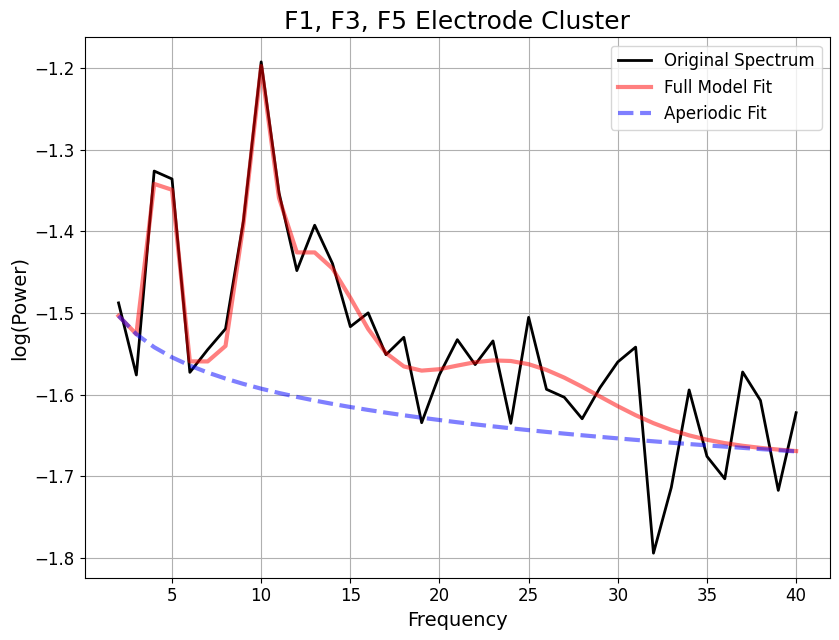

In [5]:
# Define correlations between Cz and specified electrodes
corr_factors = {
    'F1': 0.6,
    'F3': 0.6,
    'F5': 0.4
}

electrodes = ['F1', 'F3', 'F5']

# Generate signals
electrode_signals = {}

for ele, rho in corr_factors.items():
    sigma_source = np.std(cz_signal)
    noise_std = np.sqrt((1 - rho**2) / rho**2) * sigma_source
    noise = noise_std * np.random.randn(len(cz_signal))
    electrode_signals[ele] = rho * cz_signal + noise

#Compute PSD for each electrode
psds = []

for ele in electrodes:
    sig = electrode_signals[ele]
    freqs, powers = compute_spectrum_welch(sig, fs=250)
    psds.append(powers)

#Average the three PSDs
cluster_power = np.mean(psds, axis = 0)

#Fit ONE spectral model to cluster
fm_cluster = SpectralModel()
freq_range = [2, 40]

fm_cluster.fit(freqs, cluster_power, freq_range)
fm_cluster.plot(title="F1, F3, F5 Electrode Cluster")